Total Monthly Revenue: $456,116.60
Revenue Lost to Churn: $139,130.85
Revenue Loss Percentage: 30.50%



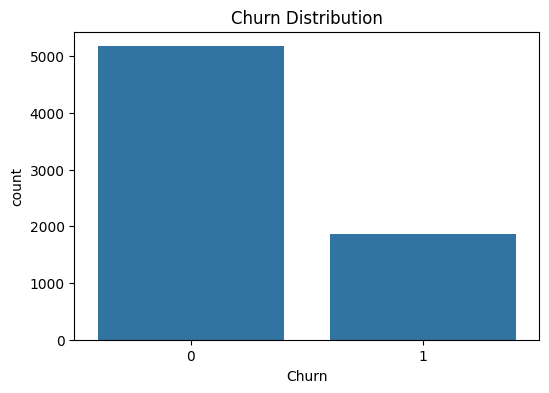

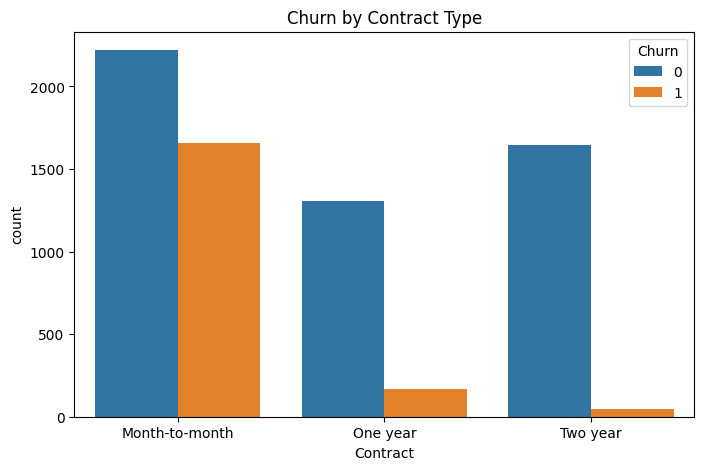

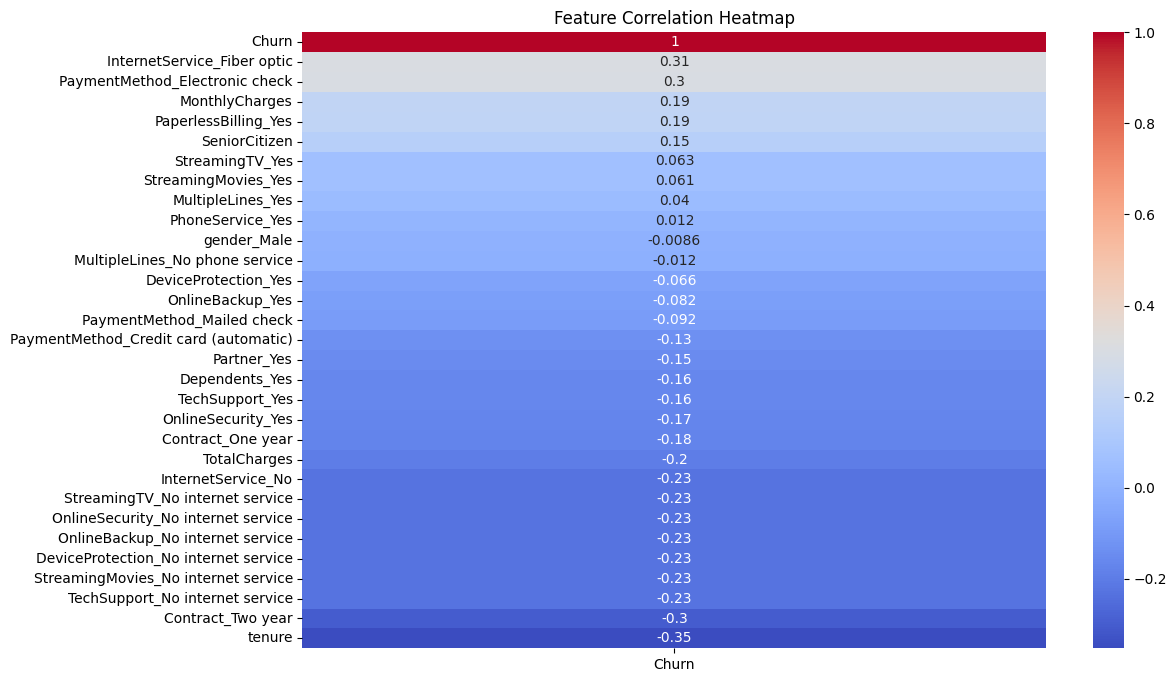

--- Logistic Regression ---
Accuracy: 0.8211
Precision: 0.6862
Recall: 0.5979
Confusion Matrix:
[[934 102]
 [150 223]]


--- Decision Tree ---
Accuracy: 0.8062
Precision: 0.7049
Recall: 0.4611
Confusion Matrix:
[[964  72]
 [201 172]]


--- Random Forest ---
Accuracy: 0.7864
Precision: 0.6406
Recall: 0.4397
Confusion Matrix:
[[944  92]
 [209 164]]


--- Final Business Insights ---
1. Contract Type: Month-to-month contracts are the biggest driver of churn. Action: Promote 1-2 year contracts with discounts.
2. Revenue Impact: The company is losing significant monthly revenue (~26-30%) due to churn. Action: Focus retention budgets on high-value customers.
3. Payment Method: Electronic Check users churn at a much higher rate. Action: Incentivize auto-pay via Credit Card.
4. Tenure Risk: New customers (first 12 months) are highly volatile. Action: Improve the onboarding experience in the first 90 days.
5. Fiber Optic Issues: Fiber Optic users have higher churn than DSL. Action: Investigate s

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop('customerID', axis=1)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

total_revenue = df['MonthlyCharges'].sum()
churn_revenue = df[df['Churn'] == 1]['MonthlyCharges'].sum()
revenue_loss_percentage = (churn_revenue / total_revenue) * 100


print(f"Total Monthly Revenue: ${total_revenue:,.2f}")
print(f"Revenue Lost to Churn: ${churn_revenue:,.2f}")
print(f"Revenue Loss Percentage: {revenue_loss_percentage:.2f}%\n")

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

plt.figure(figsize=(12, 8))
corr = df_encoded.corr()
sns.heatmap(corr[['Churn']].sort_values(by='Churn', ascending=False), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

print("--- Final Business Insights ---")
print("1. Contract Type: Month-to-month contracts are the biggest driver of churn. Action: Promote 1-2 year contracts with discounts.")
print("2. Revenue Impact: The company is losing significant monthly revenue (~26-30%) due to churn. Action: Focus retention budgets on high-value customers.")
print("3. Payment Method: Electronic Check users churn at a much higher rate. Action: Incentivize auto-pay via Credit Card.")
print("4. Tenure Risk: New customers (first 12 months) are highly volatile. Action: Improve the onboarding experience in the first 90 days.")
print("5. Fiber Optic Issues: Fiber Optic users have higher churn than DSL. Action: Investigate service reliability and technical support quality for Fiber users.")

In [2]:
1

1